<a href="https://colab.research.google.com/github/JHU-Kessler-Group/GraftedHybridLatexPaper/blob/main/Figure5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Getting Experimental Data from Github Repo

In [1]:
!rm -rf GraftedHybridLatexPaper
!git clone https://github.com/JHU-Kessler-Group/GraftedHybridLatexPaper.git


Cloning into 'GraftedHybridLatexPaper'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 144 (delta 45), reused 29 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (144/144), 17.55 MiB | 14.15 MiB/s, done.
Resolving deltas: 100% (45/45), done.


Prompt to Gemini:
"Make a graph using seaborn of the Storage Modulus vs Temperature for the four CSV files: DMA-GHL0-0.csv, DMA-GHL0-1.csv, DMA-GHL0-2.csv, and DMA-GHL0-3.csv."


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Define file paths
data_dir = '/content/GraftedHybridLatexPaper/Data/Figure5_DMA_GHL'
files = ['DMA-GHL0-0.csv', 'DMA-GHL0-1.csv', 'DMA-GHL0-2.csv', 'DMA-GHL0-3.csv']

dfs = []
for file in files:
    file_path = os.path.join(data_dir, file)
    if os.path.exists(file_path):
        # Read the CSV
        # Using try-except block in case there are parsing errors (e.g., metadata rows)
        try:
            df = pd.read_csv(file_path)
            # Add a column to distinguish the files in the plot
            df['Sample'] = file.replace('.csv', '')
            dfs.append(df)
        except Exception as e:
            print(f"Error reading {file}: {e}")
    else:
        print(f"File not found: {file_path}")

# Combine all dataframes
if dfs:
    combined_df = pd.concat(dfs, ignore_index=True)
    print("Data loaded successfully. First 5 rows:")
    display(combined_df.head())
    print("\nColumns:", combined_df.columns.tolist())
else:
    print("No data loaded.")

Data loaded successfully. First 5 rows:


,Temperature (deg C),Storage Modulus (MPa),Loss Modulus (MPpa),Tan Delta,Sample
0,-80.020,2091.9,61.916,0.029602,DMA-GHL0-0
1,-79.942,2091.4,62.013,0.029657,DMA-GHL0-0
2,-79.956,2091.5,62.000,0.029650,DMA-GHL0-0
3,-79.942,2091.4,62.013,0.029657,DMA-GHL0-0
4,-79.954,2091.5,62.002,0.029651,DMA-GHL0-0



Columns: ['Temperature (deg C)', 'Storage Modulus (MPa)', 'Loss Modulus (MPpa)', 'Tan Delta', 'Sample']


Plotting 'Storage Modulus (MPa)' vs 'Temperature (deg C)'


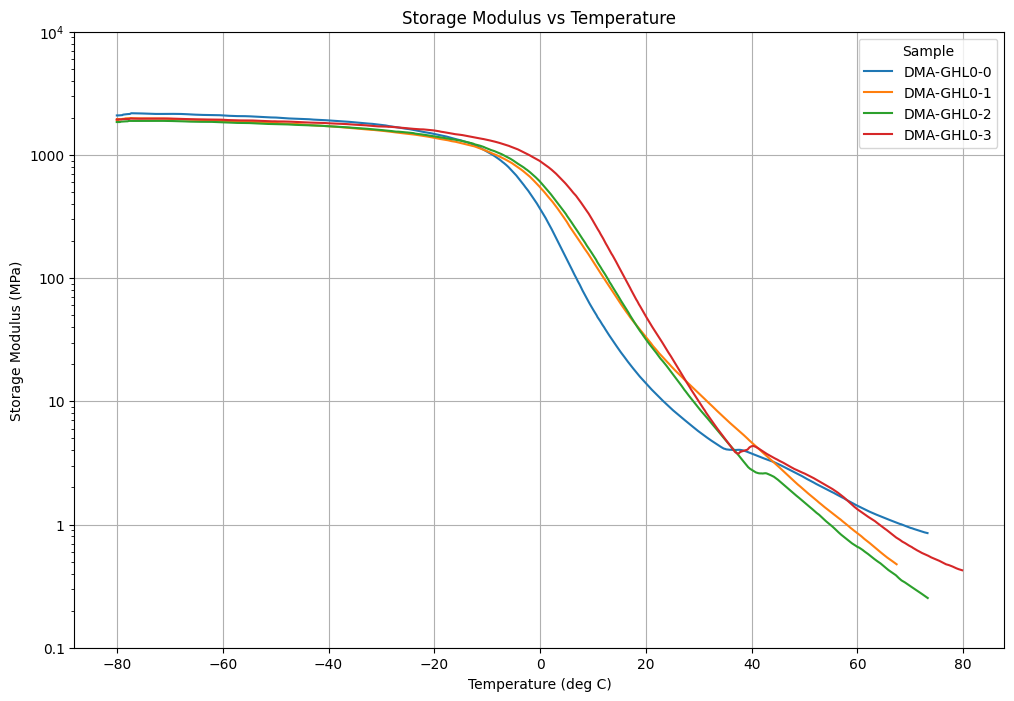

In [3]:
# Identify columns for Temperature and Storage Modulus
# This automatic detection helps if the column names have units or slight variations
temp_cols = [c for c in combined_df.columns if 'Temp' in c]
storage_cols = [c for c in combined_df.columns if 'Storage' in c]

if temp_cols and storage_cols:
    x_col = temp_cols[0]
    y_col = storage_cols[0]
    print(f"Plotting '{y_col}' vs '{x_col}'")

    plt.figure(figsize=(12, 8))
    sns.lineplot(data=combined_df, x=x_col, y=y_col, hue='Sample')
    plt.yscale('log')

    # Set y-axis range and specific ticks as requested
    plt.ylim(0.1, 10000)
    ticks = [0.1, 1, 10, 100, 1000, 10000]
    labels = ['0.1', '1', '10', '100', '1000', '$10^4$']
    plt.yticks(ticks, labels)

    plt.title('Storage Modulus vs Temperature')
    plt.grid(True)
    plt.show()
else:
    print("Could not automatically identify Temperature or Storage Modulus columns.")
    print("Available columns:", combined_df.columns)

Note, the following line of code allows the text in the SVG file to be editable in Inkscape

```
plt.rcParams['svg.fonttype'] = 'none'
```
This way, the SVG file can be adjusted later for minor changes.



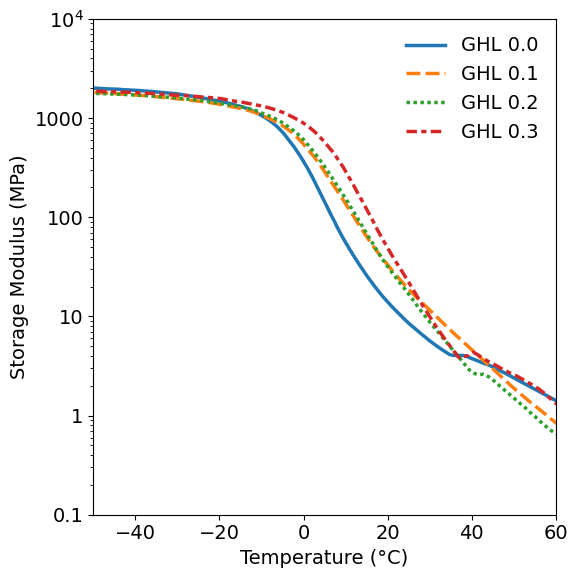

In [7]:
# Update global font size
plt.rcParams.update({'font.size': 14})

# Set SVG font type to 'none' to allow text editing in Inkscape
plt.rcParams['svg.fonttype'] = 'none'

# Create figure and axes
plt.figure(figsize=(6, 6))
ax = sns.lineplot(
    data=combined_df,
    x='Temperature (deg C)',
    y='Storage Modulus (MPa)',
    hue='Sample',
    style='Sample',
    linewidth=2.5
)

# Set y-axis to logarithmic scale
plt.yscale('log')

# Set y-axis limits
plt.ylim(0.1, 10000)

# Set x-axis limits
plt.xlim(-50, 60)

# Set custom ticks and labels for y-axis
ticks = [0.1, 1, 10, 100, 1000, 10000]
labels = ['0.1', '1', '10', '100', '1000', '$10^4$']
plt.yticks(ticks, labels)

# Turn off grid lines
plt.grid(False)

# Set x-axis label with degree symbol
plt.xlabel('Temperature (°C)')

# --- Legend modifications ---
# Get current handles and labels from the automatically generated legend
handles, current_labels = ax.get_legend_handles_labels()

# Assuming the first item in labels is the legend title ('Sample' from hue/style)
# We want to remove this if it exists.
if current_labels and current_labels[0] == 'Sample':
    handles = handles[1:] # Remove the handle for the title
    current_labels = current_labels[1:] # Remove the title label itself

# Define the mapping for sample names
label_mapping = {
    'DMA-GHL0-0': 'GHL 0.0',
    'DMA-GHL0-1': 'GHL 0.1',
    'DMA-GHL0-2': 'GHL 0.2',
    'DMA-GHL0-3': 'GHL 0.3'
}

# Create new labels based on the mapping
new_labels = [label_mapping.get(l, l) for l in current_labels]

# Recreate the legend with new labels, no title, and no frame
ax.legend(handles=handles, labels=new_labels, title='', frameon=False)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Save the plot as an SVG file
plt.savefig('storage_modulus_vs_temperature.svg')

# Display the plot
plt.show()

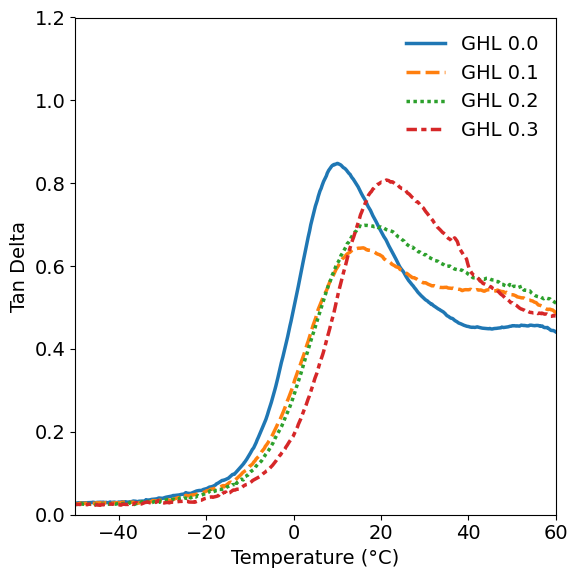

In [8]:
# Update global font size
plt.rcParams.update({'font.size': 14})

# Set SVG font type to 'none' to allow text editing in Inkscape
plt.rcParams['svg.fonttype'] = 'none'

# Create figure and axes
plt.figure(figsize=(6, 6))
ax = sns.lineplot(
    data=combined_df,
    x='Temperature (deg C)',
    y='Tan Delta',
    hue='Sample',
    style='Sample',
    linewidth=2.5
)

# Set x-axis limits (keeping consistent with previous plot)
plt.xlim(-50, 60)

# Set y-axis limits
plt.ylim(0, 1.2)

# Turn off grid lines
plt.grid(False)

# Set axis labels
plt.xlabel('Temperature (°C)')
plt.ylabel('Tan Delta')

# --- Legend modifications ---
# Get current handles and labels from the automatically generated legend
handles, current_labels = ax.get_legend_handles_labels()

# Remove the legend title if it exists
if current_labels and current_labels[0] == 'Sample':
    handles = handles[1:]
    current_labels = current_labels[1:]

# Define the mapping for sample names
label_mapping = {
    'DMA-GHL0-0': 'GHL 0.0',
    'DMA-GHL0-1': 'GHL 0.1',
    'DMA-GHL0-2': 'GHL 0.2',
    'DMA-GHL0-3': 'GHL 0.3'
}

# Create new labels based on the mapping
new_labels = [label_mapping.get(l, l) for l in current_labels]

# Recreate the legend with new labels, no title, and no frame
ax.legend(handles=handles, labels=new_labels, title='', frameon=False)

# Adjust layout
plt.tight_layout()

# Save the plot as an SVG file
plt.savefig('tan_delta_vs_temperature.svg')

# Display the plot
plt.show()

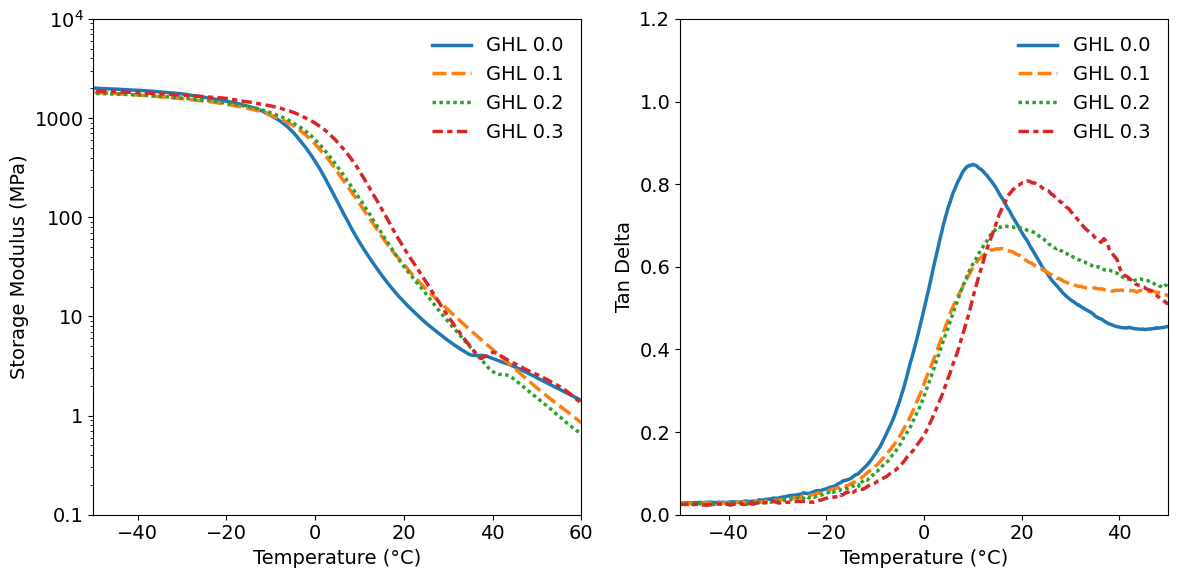

In [9]:
# Update global font size
plt.rcParams.update({'font.size': 14})

# Set SVG font type to 'none' to allow text editing in Inkscape
plt.rcParams['svg.fonttype'] = 'none'

# Create a figure with 1 row and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# --- Left Plot: Storage Modulus vs Temperature ---
sns.lineplot(
    data=combined_df,
    x='Temperature (deg C)',
    y='Storage Modulus (MPa)',
    hue='Sample',
    style='Sample',
    linewidth=2.5,
    ax=axs[0]
)

# Set y-axis to logarithmic scale
axs[0].set_yscale('log')

# Set limits
axs[0].set_ylim(0.1, 10000)
axs[0].set_xlim(-50, 60)

# Set custom ticks and labels for y-axis
ticks = [0.1, 1, 10, 100, 1000, 10000]
labels = ['0.1', '1', '10', '100', '1000', '$10^4$']
axs[0].set_yticks(ticks)
axs[0].set_yticklabels(labels)

# Turn off grid lines and set label
axs[0].grid(False)
axs[0].set_xlabel('Temperature (°C)')

# Legend for Left Plot
handles, current_labels = axs[0].get_legend_handles_labels()
if current_labels and current_labels[0] == 'Sample':
    handles = handles[1:]
    current_labels = current_labels[1:]

label_mapping = {
    'DMA-GHL0-0': 'GHL 0.0',
    'DMA-GHL0-1': 'GHL 0.1',
    'DMA-GHL0-2': 'GHL 0.2',
    'DMA-GHL0-3': 'GHL 0.3'
}
new_labels = [label_mapping.get(l, l) for l in current_labels]
axs[0].legend(handles=handles, labels=new_labels, title='', frameon=False)


# --- Right Plot: Tan Delta vs Temperature ---
sns.lineplot(
    data=combined_df,
    x='Temperature (deg C)',
    y='Tan Delta',
    hue='Sample',
    style='Sample',
    linewidth=2.5,
    ax=axs[1]
)

# Set limits
axs[1].set_xlim(-50, 50)
axs[1].set_ylim(0, 1.2)

# Turn off grid lines and set labels
axs[1].grid(False)
axs[1].set_xlabel('Temperature (°C)')
axs[1].set_ylabel('Tan Delta')

# Legend for Right Plot
handles, current_labels = axs[1].get_legend_handles_labels()
if current_labels and current_labels[0] == 'Sample':
    handles = handles[1:]
    current_labels = current_labels[1:]

new_labels = [label_mapping.get(l, l) for l in current_labels]
axs[1].legend(handles=handles, labels=new_labels, title='', frameon=False)

# Adjust layout
plt.tight_layout()

# Save the combined plot
plt.savefig('combined_dma_plots.svg')

# Display
plt.show()